# YOLOv8 Inference on Dataset Images
This notebook loads a trained YOLOv8 model and runs batched inference on the images in `yolo_dataset/images/train`. It saves predictions and visualizes a few results.

In [16]:
# 1) Import Dependencies
import os
import sys
import json
import math
import time
from pathlib import Path
from typing import List, Tuple
import numpy as np
import pandas as pd
from PIL import Image
import torch
from tqdm import tqdm
try:
    from ultralytics import YOLO  # type: ignore[attr-defined]
except Exception:
    from ultralytics.yolo.engine.model import YOLO  # type: ignore
import matplotlib.pyplot as plt

In [17]:
# 2) Configure Paths and Parameters
dataset_dir = Path('../yolo_dataset/images/train').resolve()
labels_dir = Path('../yolo_dataset/labels/train').resolve()
# Try to auto-detect best weights from last training run
default_runs = Path('../runs/train').resolve()
candidate_best = None
if default_runs.exists():
    # pick the most recent run folder that has weights/best.pt
    runs = sorted(default_runs.glob('*/weights/best.pt'), key=lambda p: p.stat().st_mtime, reverse=True)
    if runs:
        candidate_best = runs[0]
model_checkpoint = Path(os.getenv('YOLO_WEIGHTS', candidate_best if candidate_best else '../runs/train/exp/weights/best.pt')).resolve()
# Allow manual override by setting YOLO_WEIGHTS env var
class_map_path = None  # optional JSON path mapping class indices to names
output_dir = Path('../outputs/viz_infer').resolve()
output_dir.mkdir(parents=True, exist_ok=True)
batch_size = 16
num_workers = 2
image_size = 640
top_k = 1
use_mixed_precision = torch.cuda.is_available()

In [18]:
# 3) Select Device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device_name = torch.cuda.get_device_name(0) if device == 'cuda' else 'CPU'
print(f"Using device: {device} ({device_name})")

Using device: cuda (NVIDIA GeForce RTX 3080 Ti)


In [19]:
# 4) Load Trained Model
assert model_checkpoint.exists(), f"Model weights not found at {model_checkpoint}. Set YOLO_WEIGHTS env var to override."
model = YOLO(str(model_checkpoint))
# Ultralytics handles moving model to device internally during predict/train; we still track device for amp selection

In [20]:
# 5) Define Image Preprocessing
from torchvision import transforms
preprocess = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
])
# For YOLOv8 predict API, raw images are acceptable; preprocess kept for potential torch-based pipelines.
viz_transform = None  # raw display with PIL/matplotlib

In [21]:
# 6) Build Dataset and DataLoader
from glob import glob
image_paths = sorted([p for ext in ('*.jpg','*.jpeg','*.png','*.bmp','*.tif','*.tiff') for p in glob(str(dataset_dir / ext))])
print(f"Found {len(image_paths)} images under {dataset_dir}")
assert len(image_paths) > 0, f"No images found in {dataset_dir}"
# YOLO's predict method can accept list of filepaths directly, but we will do batched predict for control.

Found 149 images under /home/mateuscmarim/Projects/image_labeling/yolo_dataset/images/train


In [22]:
# 7) Warm Up (Optional)
if torch.cuda.is_available():
    _ = model.predict(source=[image_paths[0]], imgsz=image_size, device=0, verbose=False)
    torch.cuda.synchronize()
    print("Warmup done on first image.")
else:
    print("CPU mode: skipping warmup.")

Warmup done on first image.


In [23]:
# 8) Run Batched Inference
all_results = []
save_dir = output_dir / 'predictions'
save_dir.mkdir(parents=True, exist_ok=True)
batch = []
for i, img_path in enumerate(tqdm(image_paths, desc='Inferencing')):
    batch.append(img_path)
    if len(batch) == batch_size or i == len(image_paths) - 1:
        results = model.predict(
            source=batch,
            imgsz=image_size,
            device=0 if torch.cuda.is_available() else 'cpu',
            save=True,
            save_txt=True,
            save_conf=True,
            project=str(save_dir),
            name=f"batch_{i}",
            exist_ok=True,
            verbose=False,
        )
        for r in results:
            # r is a ultralytics.engine.results.Results; we capture basic metadata
            all_results.append({
                'path': r.path,
                'boxes': r.boxes.xyxy.cpu().numpy().tolist() if r.boxes is not None else [],
                'scores': r.boxes.conf.cpu().numpy().tolist() if r.boxes is not None else [],
                'classes': r.boxes.cls.cpu().numpy().tolist() if r.boxes is not None else [],
            })
        batch = []
print(f"Saved prediction visuals and txts to: {save_dir}")

Inferencing:   0%|          | 0/149 [00:00<?, ?it/s]

Results saved to /home/mateuscmarim/Projects/image_labeling/outputs/viz_infer/predictions/batch_15
10 labels saved to /home/mateuscmarim/Projects/image_labeling/outputs/viz_infer/predictions/batch_15/labels


Inferencing:  11%|█         | 16/149 [00:03<00:28,  4.75it/s]

Results saved to /home/mateuscmarim/Projects/image_labeling/outputs/viz_infer/predictions/batch_31
12 labels saved to /home/mateuscmarim/Projects/image_labeling/outputs/viz_infer/predictions/batch_31/labels


Inferencing:  21%|██▏       | 32/149 [00:05<00:20,  5.74it/s]

...

Results saved to /home/mateuscmarim/Projects/image_labeling/outputs/viz_infer/predictions/batch_143
14 labels saved to /home/mateuscmarim/Projects/image_labeling/outputs/viz_infer/predictions/batch_143/labels


Inferencing:  97%|█████████▋| 144/149 [00:25<00:00,  5.39it/s]

Results saved to /home/mateuscmarim/Projects/image_labeling/outputs/viz_infer/predictions/batch_148
7 labels saved to /home/mateuscmarim/Projects/image_labeling/outputs/viz_infer/predictions/batch_148/labels


Inferencing: 100%|██████████| 149/149 [00:25<00:00,  5.77it/s]

Saved prediction visuals and txts to: /home/mateuscmarim/Projects/image_labeling/outputs/viz_infer/predictions


In [12]:
# 9) Postprocess and Decode Predictions
names = model.names if hasattr(model, 'names') else {0: 'object'}
# Convert to DataFrame
rows = []
for rec in all_results:
    p = rec['path']
    bxs = rec['boxes']
    scs = rec['scores']
    cls = rec['classes']
    if len(bxs) == 0:
        rows.append({'filepath': p, 'num_boxes': 0, 'top1_label': None, 'top1_score': None})
    else:
        # Take the highest-score detection as top1
        mx_i = int(np.argmax(scs))
        top1_label = names.get(int(cls[mx_i]), int(cls[mx_i])) if isinstance(names, dict) else cls[mx_i]
        rows.append({'filepath': p, 'num_boxes': len(bxs), 'top1_label': top1_label, 'top1_score': float(scs[mx_i])})
pred_df = pd.DataFrame(rows)
pred_csv = output_dir / 'predictions.csv'
pred_df.to_csv(pred_csv, index=False)
print(f"Saved predictions CSV: {pred_csv}")
pred_df.head()

Saved predictions CSV: /home/mateuscmarim/Projects/image_labeling/outputs/viz_infer/predictions.csv


,filepath,num_boxes,top1_label,top1_score
0,/home/mateuscmarim/Projects/image_labeling/yol...,0,None,NaN
1,/home/mateuscmarim/Projects/image_labeling/yol...,0,None,NaN
2,/home/mateuscmarim/Projects/image_labeling/yol...,1,display,0.509745
3,/home/mateuscmarim/Projects/image_labeling/yol...,1,display,0.442396
4,/home/mateuscmarim/Projects/image_labeling/yol...,1,display,0.917043


In [13]:
# 10) Persist Predictions to Disk (already saved CSV)
# Optionally, write JSONL with full detections per image
jsonl_path = output_dir / 'predictions.jsonl'
with open(jsonl_path, 'w') as f:
    for rec in all_results:
        f.write(json.dumps(rec) + '\n')
print(f"Saved predictions JSONL: {jsonl_path}")

Saved predictions JSONL: /home/mateuscmarim/Projects/image_labeling/outputs/viz_infer/predictions.jsonl


Results saved to /home/mateuscmarim/Projects/image_labeling/outputs/viz_infer/predictions/batch_148
7 labels saved to /home/mateuscmarim/Projects/image_labeling/outputs/viz_infer/predictions/batch_148/labels


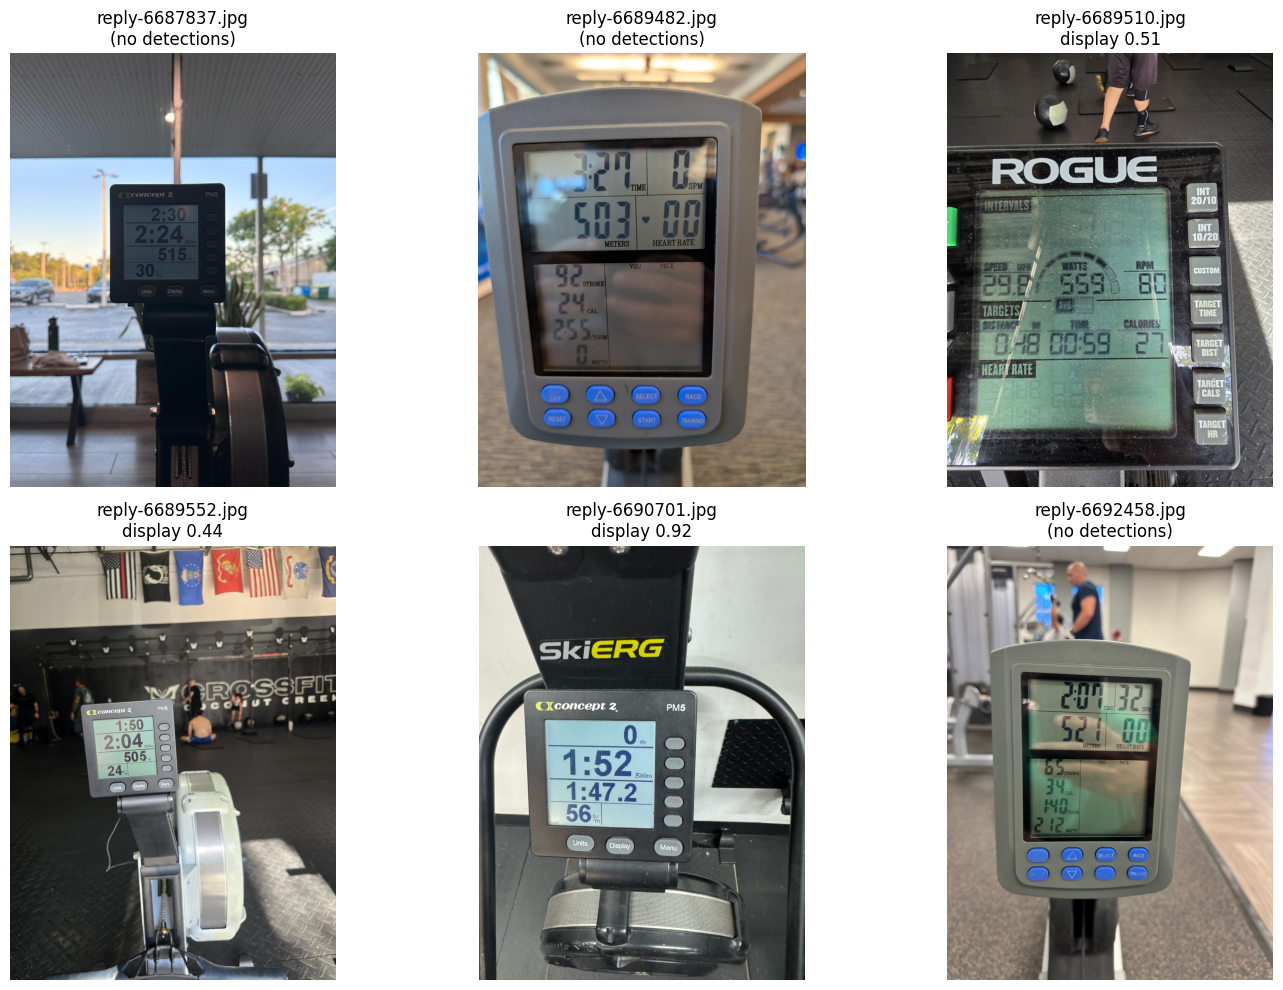

In [14]:
# 11) Visualize a Few Results
sample_count = min(6, len(image_paths))
sample_images = image_paths[:sample_count]
res = model.predict(source=sample_images, imgsz=image_size, device=0 if torch.cuda.is_available() else 'cpu', verbose=False)
cols = 3
rows = math.ceil(sample_count / cols)
plt.figure(figsize=(cols * 5, rows * 5))
for i, (img_path, r) in enumerate(zip(sample_images, res), start=1):
    plt.subplot(rows, cols, i)
    im = Image.open(img_path).convert('RGB')
    plt.imshow(im)
    # Overlay simple annotations: print the top box label and conf if exists
    if r.boxes is not None and len(r.boxes) > 0:
        confs = r.boxes.conf.cpu().numpy()
        clss = r.boxes.cls.cpu().numpy().astype(int)
        names = model.names if hasattr(model, 'names') else {}
        top_idx = int(np.argmax(confs))
        label = names.get(int(clss[top_idx]), str(clss[top_idx]))
        score = float(confs[top_idx])
        plt.title(f"{Path(img_path).name}\n{label} {score:.2f}")
    else:
        plt.title(f"{Path(img_path).name}\n(no detections)")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [15]:
# 12) Basic Unit Tests for Pipeline
# These are lightweight checks to ensure the end-to-end flow is sane.
assert model is not None, "Model failed to load"
assert len(image_paths) > 0, "No images found for inference"
# Sanity: run on one image and ensure results object has expected attributes
test_result = model.predict(source=[image_paths[0]], imgsz=image_size, device=0 if torch.cuda.is_available() else 'cpu', verbose=False)[0]
assert hasattr(test_result, 'boxes'), "Results missing boxes attribute"
print("Basic checks passed.")

Results saved to /home/mateuscmarim/Projects/image_labeling/outputs/viz_infer/predictions/batch_148
7 labels saved to /home/mateuscmarim/Projects/image_labeling/outputs/viz_infer/predictions/batch_148/labels
Basic checks passed.
Basic checks passed.
